# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [7]:
from typing import Optional

from collections import defaultdict
from enum import Enum
from datetime import datetime

import random
import numpy as np
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.providers import Backend
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import fake_provider
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.transpiler import PassManager, CouplingMap, passes
from qiskit.transpiler.passes import Optimize1qGatesDecomposition

DATA_PATH = os.path.join("..", "data")

## Noise models

In [8]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.

    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model    

In [9]:
def bitflip_model(p: float) -> NoiseModel:
    """Bitflip noise model with majority vote approach.

    Args:
        p: Probability to flip.
    Returns:
        Bit-flip noise model.
    """
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
    error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

## Constants

In [10]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3

# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [11]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
# ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
# BETA = np.deg2rad(175)
ANGLES = {PEEK: np.deg2rad(40), REVERSE_1: np.deg2rad(230), REVERSE_2: np.deg2rad(310)}
BETA = np.deg2rad(220)

In [12]:
np.cos(BETA - ANGLES[REVERSE_1] - ANGLES[PEEK])- np.cos(BETA - ANGLES[REVERSE_2] - ANGLES[PEEK]) + np.cos(BETA - ANGLES[REVERSE_1] - ANGLES[REVERSE_2]) +np.cos(BETA - ANGLES[REVERSE_2] - ANGLES[REVERSE_2]) - 2

0.8176641056110352

## Expectation values

In [13]:
def decode_results(results: dict, charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1

            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")

                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]

    return decoded_results

In [14]:
def double_expect(settings: tuple[int, int], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)

## State preparation

In [15]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [16]:
def cnot_ladder(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

In [17]:
def cnot_ladder_random(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard) for random strategy."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [18]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)

def apply_setting(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  angle: float, 
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting is PEEK:
        if strategy == "majority_vote":
            # Ask friend for the outcome.
            qc.measure(friend_qubits, observer_creg)
        elif strategy == "random":
            random_offset = random.randint(0, friend_size - 1)
            qc.measure(friend_qubits[0] + random_offset, observer)

    elif setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)
        elif strategy == "random":
            cnot_ladder_random(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)

        if observer is BOB:
            qc.h(BOB)
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)

        if strategy == "majority_vote":
            qc.measure(observer, observer_creg)
        elif strategy == "random":
            qc.measure(observer, observer)


def ewfs(alice_setting: int,
        bob_setting: int,
        strategy: str,
        angles: list[float],
        beta: float,
        charlie_size: int,
        debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice's qubit", "Bob's qubit", "Charlie", "Debbie"])
    ]

    if strategy == "majority_vote":
        if (alice_setting == PEEK and bob_setting != PEEK):
            measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
            alice_creg = list(range(charlie_size))
            bob_creg = charlie_size
        else:
            measurement = ClassicalRegister(meas_size, name="Measurement")
            alice_creg = 0
            bob_creg = 1
    elif strategy == "random":
        measurement = ClassicalRegister(sys_size, name="Measurement")
        alice_creg, bob_creg = 0, 0
    else:
        raise ValueError(f"Strategy: {strategy} is not defined.")

    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = list(range(sys_size, (sys_size + charlie_size)))
    debbie_qubits = list(range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size)))

    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)

    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    if strategy == "majority_vote":
        cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
        cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)
    elif strategy == "random":
        cnot_ladder_random(qc, ALICE, charlie_qubits[0], charlie_size)
        cnot_ladder_random(qc, BOB, debbie_qubits[0], debbie_size)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, strategy, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, strategy, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    return qc

## Sanity checks (for majority vote approach)

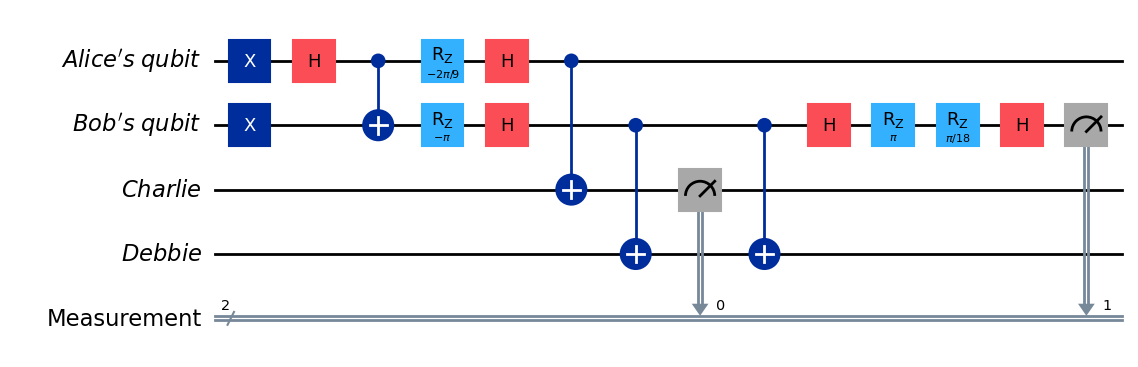

In [19]:
# Print example circuit.
charlie_size = 1
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
qc.draw("mpl", style="default")#.savefig("ewfs_majority_vote_peek_reverse_1.pdf")

In [20]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakePerth,FakeKolkataV2, FakeOsaka

backend = AerSimulator.from_backend(FakeOsaka())

## Check if residual matrix is a density matrix

In [26]:
import qiskit
from qiskit_aer import Aer
from qiskit.quantum_info import state_fidelity

from qiskit_experiments.framework import ParallelExperiment
from qiskit_experiments.library import StateTomography

charlie_size = 1
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)

backend = AerSimulator.from_backend(FakeOsaka())

job = Aer.get_backend('statevector_simulator').run(qc, shots=1e4)
psi = job.result().get_statevector(qc).data


# QST Experiment
qstexp1 = StateTomography(qc)
qstdata1 = qstexp1.run(backend, seed_simulation=100).block_for_results()

# Print results
# for result in qstdata1.analysis_results():
#     print(result)

rho = qstdata1.analysis_results()[0].value.data

F = psi.T @ rho @ psi 

print(F)

rho_p = (rho - F * psi @ psi.conj().T) / (1-F)

def check_psd(mat, atol=1e-8):
    evals, _ = np.linalg.eigh(mat)
    return all(x >= -abs(atol) for x in evals)

check_psd(rho_p)


(0.3428540026964277-3.9150904564451095e-16j)


False

## Simulate noisy density matrices of the EWFS circuit

In [16]:
import pickle
import qiskit
from qiskit_aer import Aer
from qiskit.quantum_info import state_fidelity

from qiskit_experiments.framework import ParallelExperiment
from qiskit_experiments.library import StateTomography


backend = AerSimulator.from_backend(FakeOsaka())

friend_sizes = list(range(1,4))
density_matrices = []

for charlie_size in friend_sizes:
    setting = (PEEK, REVERSE_1)
    qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)

    # QST Experiment
    qstexp1 = StateTomography(qc)
    qstdata1 = qstexp1.run(backend, seed_simulation=100).block_for_results()

    # Print results
    # for result in qstdata1.analysis_results():
    #     print(result)

    rho = qstdata1.analysis_results()[0].value.data
    density_matrices.append(rho)

with open('noisy_density_matrices.pkl', 'wb') as handle:
    pickle.dump(density_matrices, 
                handle, protocol=pickle.HIGHEST_PROTOCOL)    

In [ ]:
with open("noisy_density_matrices.pkl", "rb") as handle:
    density_matrices = pickle.load(handle)

## Run on real hardware

In [22]:
IBM_PROVIDER_TOKEN="6067c1d7a41b12767c21eabc115c794c127731f073c041f9bda8fa013be679d6a85834ae12267511cc76269c558be50421e4849a860427739658b5b289483a44"

QiskitRuntimeService.save_account(channel="ibm_quantum", token=IBM_PROVIDER_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

In [ ]:
backend = service.backend("ibm_brisbane")
# backend = AerSimulator.from_backend(FakeOsaka())

friend_sizes = list(range(1,4))
density_matrices = []

for charlie_size in friend_sizes:
    setting = (PEEK, REVERSE_1)
    qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)

    # QST Experiment
    qstexp1 = StateTomography(qc)
    qstdata1 = qstexp1.run(backend, seed_simulation=100).block_for_results()

    # Print results
    # for result in qstdata1.analysis_results():
    #     print(result)

    rho = qstdata1.analysis_results()[0].value.data
    density_matrices.append(rho)

In [ ]:
backend = service.backend("ibm_osaka")

# QST Experiment
qstexp1 = StateTomography(qc)
qstdata1 = qstexp1.run(backend, seed_simulation=100).block_for_results()

# Print results
for result in qstdata1.analysis_results():
    print(result)

/Users/farrokhlabib/Documents/github/wigners_friend/.venv/lib/python3.10/site-packages/qiskit_experiments/framework/base_experiment.py:351: UserWarning: seed_simulation is not a recognized runtime option and may be ignored by the backend.
  jobs = [self.backend.run(circs, **run_options) for circs in job_circuits]


AnalysisResult
- name: state
- value: DensityMatrix([[ 2.40279468e-02+0.00000000e+00j,
                 1.08644281e-02-7.97087313e-03j,
                -1.25037549e-03+1.68426079e-03j,
                -1.42109346e-04+4.42978278e-03j,
                 8.10172376e-04+9.14754234e-04j,
                 7.17401706e-04-2.26078277e-03j,
                -1.28552134e-03-1.41351984e-03j,
                 3.48105991e-04-3.09550906e-04j,
                -5.18349890e-04+5.19751110e-04j,
                 1.49664932e-03-1.43797013e-03j,
                 4.12613810e-04-1.02239355e-03j,
                -3.32739257e-03-1.13654053e-03j,
                -2.49191528e-03+1.21789654e-03j,
                 5.01142761e-03+1.20168174e-03j,
                -5.00740919e-03+4.73691193e-03j,
                -6.82601787e-03+6.16081444e-04j],
               [ 1.08644281e-02+7.97087313e-03j,
                 4.23450923e-01-8.90165633e-18j,
                 1.21759454e-02-2.18752111e-02j,
                -8.71662425e-0

In [ ]:
fid_result = qstdata1.analysis_results("state_fidelity")
print("State Fidelity = {:.5f}".format(fid_result.value))

State Fidelity = 0.82040


$\frac{1}{\sqrt{2}} (\ket{01} \ket{0^n}- \ket{10}\ket{1^n})$

## Number of gates in EWFS circuit of running on IBM hardware

In [21]:
#helper function to get number of basis gates used in ansatz
def total_gates(circuit):
    gates = circuit.count_ops()

    total_gates = sum(gates.values())
    return total_gates

In [22]:
# backend = AerSimulator.from_backend(FakeKolkataV2())
# backend = AerSimulator.from_backend(FakePerth())
backend = AerSimulator.from_backend(FakeOsaka())
# backend = AerSimulator.from_backend(FakeTorino())

friend_sizes = list(range(1,10))
gates = []
for charlie_size in friend_sizes:
    setting = (PEEK, REVERSE_1)
    qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
    qc_transpiled = transpile(qc, backend=backend)
    total = total_gates(qc_transpiled)
    gates.append(total)

Text(0, 0.5, 'Total gates')

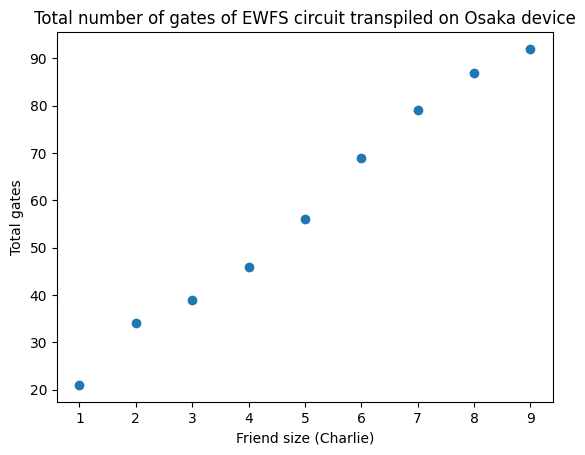

In [24]:
plt.scatter(friend_sizes, gates)
plt.title(f'Total number of gates of EWFS circuit transpiled on Osaka device')
plt.xlabel('Friend size (Charlie)')
plt.ylabel('Total gates')